### 24RB1075 小嶋将太郎

### 課題１

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
m = 100 # データ数
w = np.random.randn(1,1) # wを得る

X = np.random.uniform(-1,1,(m,1)) # Xを得る
e = np.random.randn(m,1) * 0.1 # ノイズeを決める
y = X @ w + e

D = np.hstack([X,y])
D

array([[-0.95934782,  0.74721387],
       [ 0.94701072, -0.69867435],
       [ 0.14936945, -0.15102959],
       [ 0.17040446, -0.08362687],
       [-0.74151027,  0.64074216],
       [-0.38370541,  0.31053635],
       [ 0.34024178, -0.26737308],
       [-0.5534489 ,  0.40874493],
       [ 0.13736025, -0.17296034],
       [ 0.58051801, -0.43163647],
       [ 0.95860006, -0.6041151 ],
       [-0.68955955,  0.5836379 ],
       [ 0.82932937, -0.53631096],
       [ 0.03810147,  0.1378913 ],
       [-0.19559132,  0.29472593],
       [ 0.58131497, -0.41527172],
       [-0.76090079,  0.69479942],
       [-0.74455771,  0.66603036],
       [-0.29095243,  0.25756211],
       [-0.84490095,  0.72206919],
       [-0.48315987,  0.27535488],
       [ 0.17559455, -0.18547074],
       [-0.99755309,  0.7897031 ],
       [-0.33508007,  0.27444823],
       [ 0.95652755, -0.69780729],
       [-0.4710995 ,  0.33953452],
       [ 0.66405582, -0.50588348],
       [-0.43557231,  0.42839647],
       [ 0.61967018,

In [3]:
X_eval = np.random.uniform(-1,1,(m,1))
e_eval = np.random.randn(m,1) * 0.1
y_eval = X_eval @ w + e_eval
E = np.hstack([X_eval,y_eval])
E

array([[-0.57284014,  0.54450586],
       [-0.36558431,  0.16038528],
       [ 0.58093867, -0.44153507],
       [-0.25838783,  0.2021012 ],
       [-0.91077271,  0.68609145],
       [ 0.40569176, -0.22408725],
       [-0.43452423,  0.18329853],
       [ 0.93822887, -0.38400505],
       [ 0.02191243,  0.17608843],
       [-0.73159487,  0.58611936],
       [-0.68214449,  0.4769171 ],
       [-0.99069931,  0.61800046],
       [ 0.03706715, -0.1349918 ],
       [ 0.91745765, -0.81313811],
       [ 0.28199038, -0.192007  ],
       [ 0.94249969, -0.86610211],
       [-0.32342077,  0.37260666],
       [ 0.34907092, -0.40467496],
       [-0.71850545,  0.60370838],
       [ 0.01964199, -0.02471228],
       [ 0.17694914, -0.10497726],
       [-0.38405259,  0.36845212],
       [ 0.84135568, -0.48825889],
       [ 0.81295707, -0.55472633],
       [ 0.63720566, -0.32552045],
       [ 0.36078437, -0.40233989],
       [-0.53085113,  0.39979058],
       [ 0.08670025,  0.00262521],
       [ 0.06473341,

### 課題2

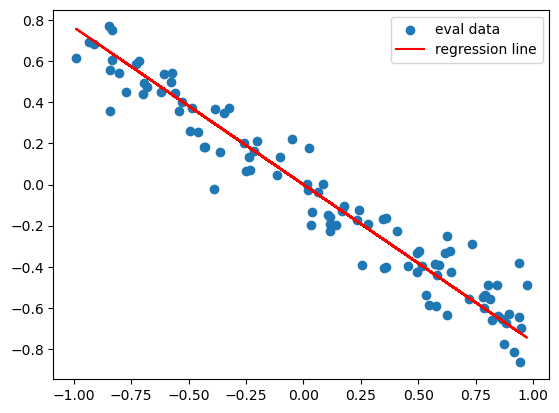

In [4]:
w_hat = np.sum(X*y) / np.sum(X**2)
y_hat = X_eval * w_hat

plt.scatter(X_eval, y_eval, label='eval data')
plt.plot(X_eval, y_hat, label='regression line', color='red')

plt.legend()
plt.show()


In [5]:
for m in [100, 500, 1000, 10000]:
    
    # 学習データ D
    X = np.random.uniform(-1, 1, (m,1))
    e = np.random.randn(m,1) * 0.1
    y = X * w + e

    # 推定
    w_hat = np.sum(X * y) / np.sum(X**2)

    # 評価データ E
    X_eval = np.random.uniform(-1, 1, (m,1))
    e_eval = np.random.randn(m,1) * 0.1
    y_eval = X_eval * w + e_eval

    # 誤差
    y_hat = X_eval * w_hat
    error = np.sum((y_eval - y_hat)**2)
    mse = error / m

    print(f"m={m}, error={error:.3f}, mse={mse:.3f}")

m=100, error=1.232, mse=0.012
m=500, error=3.978, mse=0.008
m=1000, error=10.131, mse=0.010
m=10000, error=99.874, mse=0.010


In [6]:
print("w:", w)

for m in [100, 500, 1000, 10000]:
    X = np.random.uniform(-1,1,(m,1))
    e = np.random.randn(m,1)*0.1
    y = X * w + e

    w_hat = np.sum(X*y)/np.sum(X**2)
    print(f"m={m}, w_hat={w_hat}")

w: [[-0.75154576]]
m=100, w_hat=-0.754346712276225
m=500, w_hat=-0.7322709849282832
m=1000, w_hat=-0.7502131192837038
m=10000, w_hat=-0.7514828501451497


In [7]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

data = load_diabetes()

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

### 課題3

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import numpy as np

for m in [50, 100, 200, 300, 400]:

    X_sub = X[:m]
    y_sub = y[:m]

    X_train, X_test, y_train, y_test = train_test_split(
        X_sub, y_sub, test_size=0.3, random_state=0
    )

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    mse = np.mean((y_test - y_pred)**2)

    print(f"m={m}, MSE={mse:.2f}")

m=50, MSE=2862.25
m=100, MSE=2617.35
m=200, MSE=3195.31
m=300, MSE=3380.94
m=400, MSE=3180.99


In [9]:
for m in [50, 100, 200, 300, 400]:

    X_sub = X[:m]
    y_sub = y[:m]

    model = LinearRegression()
    model.fit(X_sub, y_sub)

    print(f"m={m}, w={model.coef_[0]:.3f}")

m=50, w=-36.534
m=100, w=31.943
m=200, w=-31.887
m=300, w=-16.573
m=400, w=5.029
